<a href="https://colab.research.google.com/github/manuelagutierrezss16/Integraci-n-de-Datos-y-Prospectiva/blob/main/2_Integraci%C3%B3n_Datos_Cosco_x_Evergreen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caso Estudio - Primer Método Integración**

El primer método de integración se conoce como el método de muestreo (muestreo por clusterización - Montecarlo). Este método esta determinado por el índice de confiabilidad. De manera general la confiabilidad a norma internacional esta marcado por una confiabilidad del 99.9%, lo que requerira como minimo tener un total de 1000 datos.

#0. Cargamos las librerias de trabajo

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns  #Las gráficas estadísticas
import matplotlib.pyplot as plt

1. Cargamos los datos de trabajo

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


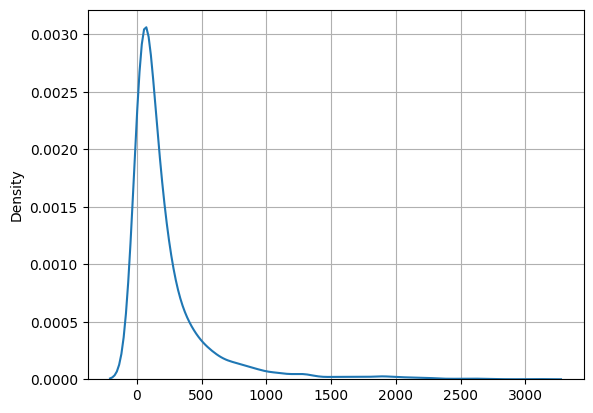

In [ ]:
nxl='/content/1. RiesgoOperacional_EVERGREEEN.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
#display(XDB)
Freq=XDB.iloc[:,3]; Sev=XDB.iloc[:,4]
LDA=Freq*Sev

plt.figure()
sns.kdeplot(LDA)
plt.grid()
plt.show()

2. Se procede con la creación de los concentradores de información

In [ ]:
import random
random.seed(42)
XC=np.array(random.choices(LDA,k=5))
XC=np.sort(XC)
print("Los concentradores de información son:",XC)

Los concentradores de información son: [ 66.68668397  83.48720974  85.08350368 192.09214682 203.24462183]


3. Se clasifican los datos de acuerdo con los concentradores de información

In [ ]:
box0=[];box1=[];box2=[];box3=[];box4=[]
Boxes=[box0,box1,box2,box3,box4]

for k in range(len(LDA)):
  d=np.abs(XC-LDA.iloc[k,])/XC #la distancia de un dato a un concentrador
  nc=np.argmin(d)  #Número de la caja en donde voy a introducir el dato
  # IMPORTANTE No olvidar actualizar el centroide de la caja
  XC[nc,]=(XC[nc,]+LDA.iloc[k,])/2  #Actualizamos el centroide de la caja

  Boxes[nc].append(LDA.iloc[k,])

#Determinamos el porcentaje de datos por Caja
pm=[]  #Vector de porcentajes
for j in range(5):
  pd=len(Boxes[j])/len(LDA)
  pm.append(pd)

pm=(np.array(pm)*1000).astype(int)
print("El porcentaje de los datos es:",pm)

El porcentaje de los datos es: [ 29  58 136 279 495]


4. Sacamos daticos por caja y creamos una LDA2

la media de los datos observados es: 231.2666023410175
la media de los datos externos es: 229.8465241904529
El error relativo porcentual es: 0.614043764291826


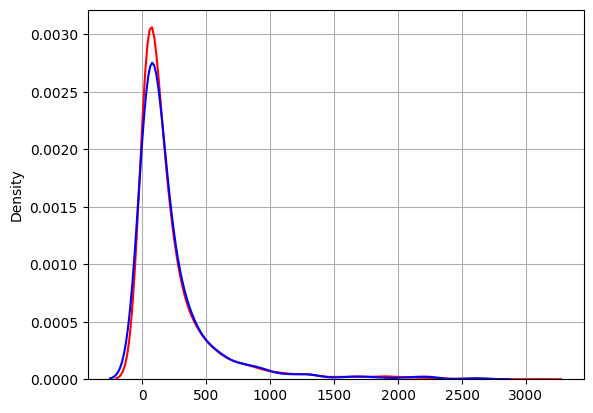

In [ ]:
LDA2=[]  #Aquí van a quedar los 1000 datos

for j in range(5):
  LDA2.extend(random.choices(Boxes[j],k=pm[j]))

LDA2=np.array(LDA2)

#Se comprueban las métricas estadísticas
uo=np.mean(LDA)
print("la media de los datos observados es:",uo)
ue=np.mean(LDA2)
print("la media de los datos externos es:",ue)

# **NP.ABS ES PARA QUE SOLO ME DE DATOS POSITIVOS ES MUY IMPORTANTE !!**

du=np.abs((uo-ue)/uo)

print("El error relativo porcentual es:",du*100)

plt.figure()
sns.kdeplot(LDA,color='red',label='Datos Observados')
sns.kdeplot(LDA2,color='blue',label='Datos Externos')
plt.grid()
plt.show()
#

**Análisis de Resultados**
De acuerdo con el método de integración de datos por muestreo aleatorio y concentradores de información, la discrepancia que se obtuvo para la media de las distribuciones (Datos Observados:LDA, Datos Externos:LDA2) estuvo por debajo del 5% en promedio, lo que indica que el 95% de los datos aproximadamente fueron correctamente seleccionados. Este proceso de muestreo se hizo con el fin de lograr una confiabilidad del 99,9% en la estimación de las pérdidas por dejar contenedores en tierra. Es importante mencionar que las medias de los datos observadoes y los externos fueron bla, bla, bla, las desviaciones fueron bla, bla, bla, los coeficientes asimetría fueron tales y tales, y la curtosis fueron tales y tales (es que fueron muy similares).

#**Integrar base de datos COSCO (Datos externos)**

En esta parte la naviera Evergrren quiere integrar los datos logisticos de la operacion de cosco shipping, par alo cual utilizara el modelo K-medoids

1. Se carga la base de sqatos externa


,Mensual,Transacción Mensuales (Mes),Valor Transado (MUSD),Eventos (Mes),Severidad (KUSD)
0,1,16,16.840771,1,0.971171
1,2,66,31.694407,8,2.267038
2,3,127,16.901201,10,0.975352
3,4,113,25.340976,11,4.453477
4,5,192,24.096199,16,2.937216
...,...,...,...,...,...
495,496,22,11.492619,2,1.471331
496,497,91,41.608338,3,2.618779
497,498,29,54.306981,3,5.996600
498,499,126,143.389211,19,15.343642


La media de los datos es: 60.70724412540753
 El coeficiente de asimetria (skewness) es 12.024762972960977


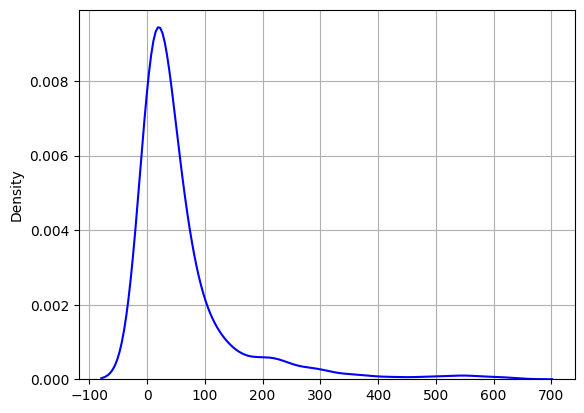

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nxle='/content/3. Datos COSCO Shipping.xlsx'
XDBe=pd.read_excel(nxle,sheet_name=0)
display(XDBe)

Freqe= XDBe.iloc[:,3]; Seve=XDBe.iloc[:,4]
LDAe=Freqe*Seve
print("La media de los datos es:", np.mean(LDAe))
print(" El coeficiente de asimetria (skewness) es", LDAe.kurtosis())

plt.figure()
sns.kdeplot(LDAe,color='blue')
plt.grid()
plt.show()

2. Se procede con la integración de los datos externos

In [ ]:
# Esto solo se debe ejecutar 1 vez, si lo hago varias veces olo engordol las boxes


LDAe= np.array(LDAe)
(XC-LDAe[0,])/XC # A cual caja pertenece el dato

#Valor de pertenencia para solo 1 dato
#VP=np.exp(-0.5*((XC-LDAe[0,])/XC)**2)
#print("Los valores de pertenencia a los clusters internos son:",VP)
# Si no son mayores al 90 son valores basura, acá ninguno sirve

#if np.argmax(VP)>0.90:
  #print("Se integra el dato")
  #nc= np.argmax(VP)
  #Boxes[nc].append(LDAe[0,])
  #XC[nc,]=(XC[nc,]+LDAe[0,])/2

# Vaolor de pertenencia conjunto total de datos

m1=0 #Cuantos datos e integrado
for k in range(len(LDAe)):
  VP=np.exp(-0.5*((XC-LDAe[k,])/XC)**2)
  if np.max(VP)>0.90:
   m1=m1+1
   nc= np.argmax(VP)
   Boxes[nc].append(LDAe[k,])
   XC[nc,]=(XC[nc,]+LDAe[k,])/2

print("Los datos integrados fueron:",m1)


Los datos integrados fueron: 302


3. Se procede con el muestreo de las cajas


La media es: 231.2666023410175
La media de los datos muestreados 229.8465241904529
La media de los datos muestrados con los datos externos es: 211.1671087812205
Skewness for LDA (Datos Observados): 3.390871982960723
Skewness for LDA2 (Datos Externos - Montecarlo): 3.422439296495657
Skewness for LDA2e (Datos Externos - COSCO Shipping): 4.055843382645293


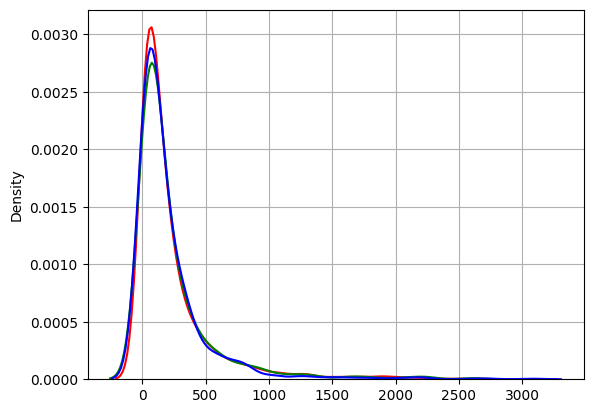

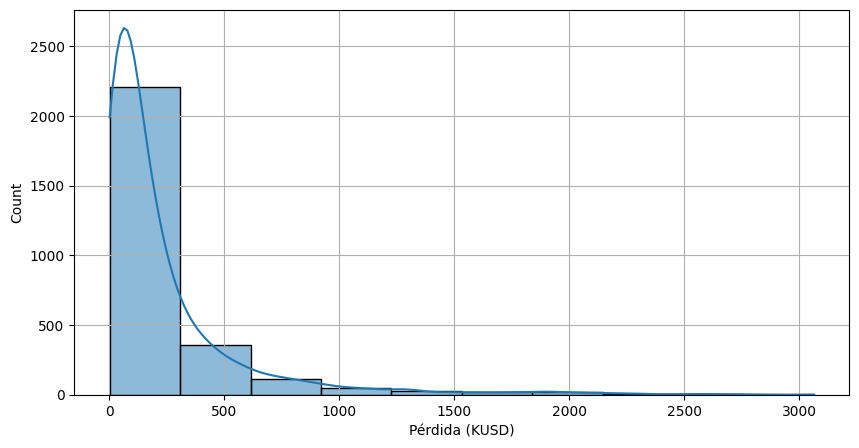

El número de datos por intervalo es:
[2209  356  116   46   27   18   20    7    4    1]
Los intervalos inferiores:
[   2.59919687  308.92945016  615.25970344  921.58995673 1227.92021002
 1534.25046331 1840.5807166  2146.91096988 2453.24122317 2759.57147646]
Los intervalos superiores:
[ 308.92945016  615.25970344  921.58995673 1227.92021002 1534.25046331
 1840.5807166  2146.91096988 2453.24122317 2759.57147646 3065.90172975]
la media de la distribucion original es: 279.6510949925361
el coeficiente de asumetria para la distribucion origunal es: 3.792311305904773


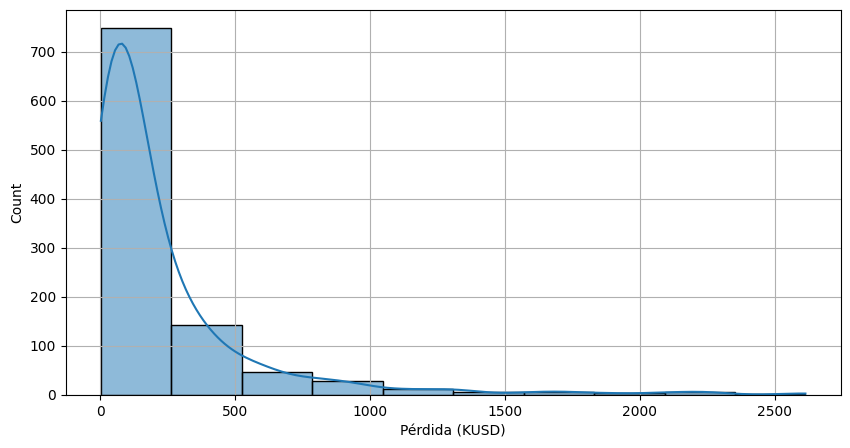

El número de datos por intervalo es:
[748 142  46  27  12   6   5   3   6   2]
Los intervalos inferiores:
[   2.68468013  263.8758335   525.06698688  786.25814026 1047.44929363
 1308.64044701 1569.83160038 1831.02275376 2092.21390714 2353.40506051]
Los intervalos superiores:
[ 263.8758335   525.06698688  786.25814026 1047.44929363 1308.64044701
 1569.83160038 1831.02275376 2092.21390714 2353.40506051 2614.59621389]
la media de la distribucion Muestreada es: 266.88856997635946
el coeficiente de asumetria para la distribucion Muestreada es: 3.67855989493065


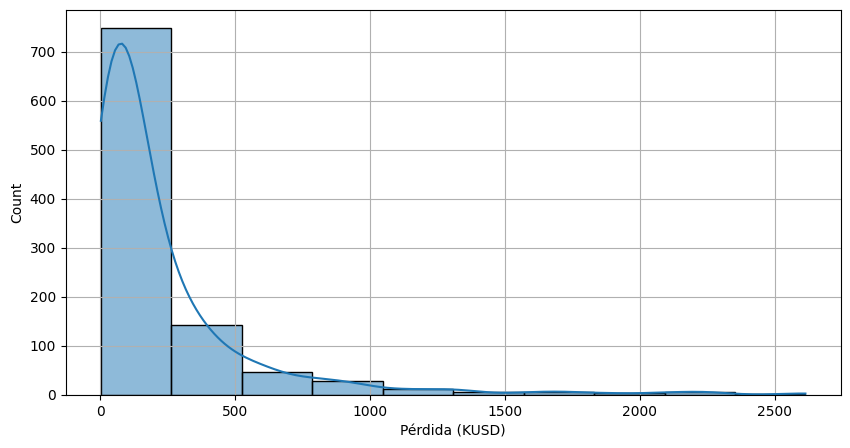

El número de datos por intervalo es:
[748 142  46  27  12   6   5   3   6   2]
Los intervalos inferiores:
[   2.68468013  263.8758335   525.06698688  786.25814026 1047.44929363
 1308.64044701 1569.83160038 1831.02275376 2092.21390714 2353.40506051]
Los intervalos superiores:
[ 263.8758335   525.06698688  786.25814026 1047.44929363 1308.64044701
 1569.83160038 1831.02275376 2092.21390714 2353.40506051 2614.59621389]
la media de la distribucion Muestreada de datos externos es: 266.88856997635946
el coeficiente de asumetria para la distribucion Muestreada de datos externos es: 3.67855989493065
la discrepancia de la media es: 0.04563731465638382
la discrepancia de la media es: 0.04563731465638382


In [ ]:
LDA2e=[] # Aq1ui quedan los 1000 datos
for j in range(5):
   LDA2e.extend(random.choices(Boxes[j],k=pm[j]))

LDA2e=np.array(LDA2e)

print("La media es:",np.mean(LDA))
print("La media de los datos muestreados",np.mean(LDA2))
print("La media de los datos muestrados con los datos externos es:",np.mean(LDA2e))

import scipy.stats as stats

print("Skewness for LDA (Datos Observados):", LDA.skew())
print("Skewness for LDA2 (Datos Externos - Montecarlo):", stats.skew(LDA2))
print("Skewness for LDA2e (Datos Externos - COSCO Shipping):", stats.skew(LDA2e))


plt.figure()
sns.kdeplot(LDA,color='red',label='Datos Observados')
sns.kdeplot(LDA2,color='green',label='Datos Muestreados')
sns.kdeplot(LDA2e,color='blue',label='Datos Externos')
plt.grid()
plt.show()

# Se muestran las métricas para cada distribución
u1,p2,p3,p4,p5= caracterizacion(LDA)
print("la media de la distribucion original es:",u1)
print("el coeficiente de asumetria para la distribucion origunal es:",p3)

# Se muestran las métricas para cada distribución
u2,p2,p3,p4,p5= caracterizacion(LDA2)
print("la media de la distribucion Muestreada es:",u2) # Se cambio p1 por u2
print("el coeficiente de asumetria para la distribucion Muestreada es:",p3)

# Se muestran las métricas para cada distribución
u3,p2,p3,p4,p5= caracterizacion(LDA2)
print("la media de la distribucion Muestreada de datos externos es:",u3) # Se cambio p1 por u3
print("el coeficiente de asumetria para la distribucion Muestreada de datos externos es:",p3)

print("la discrepancia de la media es:",np.abs((u1-u2)/u1)) #siempre se compara con el valor original
print("la discrepancia de la media es:",np.abs((u1-u3)/u1)) # Debe ser menor a 5% = 0.05

Se integra el metodo para la caracterización para las cariables aleatorias

In [ ]:
def caracterizacion(LDA):

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("Pérdida (KUSD)")
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(LDA,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  df.head(10)

  #Se procede con la estimación de la media
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  return u,sigma,Cas,Kur,df # Orden p1, p2, p3... o le puedo cambiar el nombre u1,

Analisis de Resultados

De acuerdo con la base de datos de la naviera cosco shipping se logro la integracion de un totla de 302 datos  (parte 2. )a un valor de pertenencia del 90 % a cada una de las categorias de riesgo originales. COn respecto a la media de los datos originales 279,65 usd/contenedor, los datos muestreados tuvieron una discrepancia con respecto a la media de 4,5% con respecto a los datos originale sy la discrepancia con respecto a los datos integrados fue del 4,5% aproximadamente.

Si el valor de discrepancia es muy alto se sugiere incrementar el valor de pertenencia (del 90 al 95 %) esto con el fin de integrar los datos con mayor afinidad. De manera general en las graficas anteriores se puede observar uqe las distibuciones conservaron la misma estructura ( distribuciones esbeltas de cola larga con coeficientes de asimetria en promedio cercanos a 3,5)

Crear una base de datos externa similar a mi caso de estudio... algo asi para la entrega